In [39]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

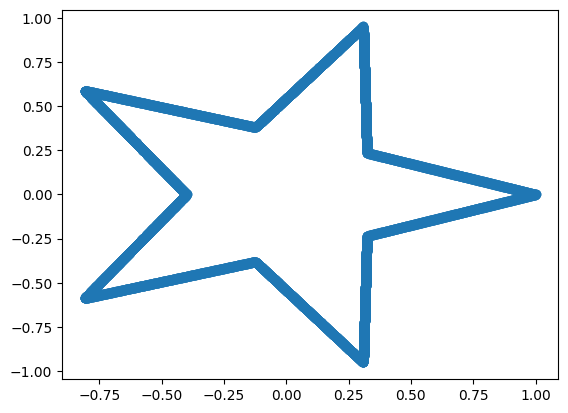

In [40]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [41]:
class Config:
    sigma_min = 0.01
    sigma_max = 4.0

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

In [42]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [43]:
def sigma_t(t, config):
    return config.sigma_min * (config.sigma_max / config.sigma_min) ** t

def g_t(t, config):
    sigma = sigma_t(t, config)
    c = math.sqrt(2.0 * math.log(config.sigma_max / config.sigma_min))

    return sigma * c

In [44]:
class VETrainer:
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0
        for (batch,) in self.dataloader:
            batch = batch.to(self.device)
            t = torch.rand(batch.shape[0], 1, device=self.device)
            sigma = sigma_t(t, self.config)
            eps = torch.randn_like(batch)
            x_t = batch + sigma * eps

            pred_eps = self.model(x_t, t)
            loss = F.mse_loss(pred_eps, eps)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        return total_loss / len(self.dataloader)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            if n % 100 == 0:
                print(f'Epoch {n}: loss = {loss:.6f}')

In [45]:
config = Config()
trainer = VETrainer(config)

In [46]:
trainer.run()

Epoch 0: loss = 0.913593
Epoch 100: loss = 0.648131
Epoch 200: loss = 0.638969
Epoch 300: loss = 0.618327
Epoch 400: loss = 0.639438
Epoch 500: loss = 0.595389
Epoch 600: loss = 0.601511
Epoch 700: loss = 0.588424
Epoch 800: loss = 0.560603
Epoch 900: loss = 0.579109
Epoch 1000: loss = 0.548824
Epoch 1100: loss = 0.569088
Epoch 1200: loss = 0.557421
Epoch 1300: loss = 0.550771
Epoch 1400: loss = 0.562919
Epoch 1500: loss = 0.561382
Epoch 1600: loss = 0.538260
Epoch 1700: loss = 0.528965
Epoch 1800: loss = 0.523562
Epoch 1900: loss = 0.543157


In [47]:
def sample(model, config, num_samples=1000):
    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples,2,device=device)*config.sigma_max

        dt = 1.0/config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i*dt
            t = max(t,1e-5)

            t_tensor = torch.full((num_samples,1),t,device=device)

            sigma = sigma_t(t_tensor,config)
            gt = g_t(t_tensor,config)

            pred = model(x,t_tensor)
            score = -pred/sigma

            drift = (gt**2)*score*dt

            if i < config.num_timesteps-1:
                diffusion = gt*torch.randn_like(x)*math.sqrt(dt)
            else:
                diffusion = 0

            x = x + drift + diffusion

        return x.cpu().numpy()

In [48]:
samples = sample(trainer.model, trainer.config, 1000)

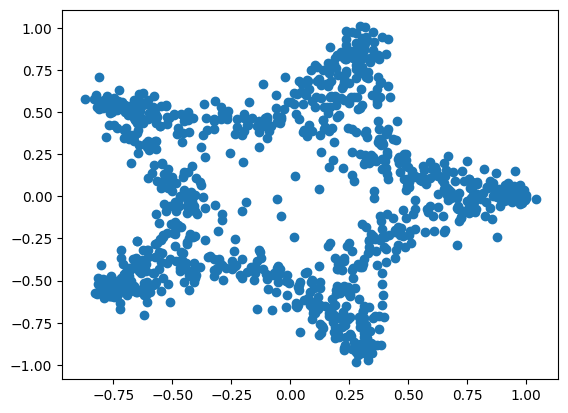

In [49]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

In [50]:
class VPConfig:
    def __init__(self, schedule='linear', beta_min=0.0001, beta_max=0.02, T=1000):
        self.schedule = schedule
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.T = T
        self.lr = 1e-3
        self.epochs = 2000
        self.batch_size = 512
        self.hidden_dim = 256
        self.data_samples = 5000


In [51]:
def beta_t(t, config):
    if config.schedule == 'linear':
        return config.beta_min + t * (config.beta_max - config.beta_min)

    elif config.schedule == 'cosine':
        s = 0.008
        angle = (t + s) / (1 + s) * math.pi / 2
        beta = (math.pi / (1 + s)) * torch.tan(angle)
        return torch.clamp(beta, min=1e-6, max=20.0)

In [52]:
def alpha_t(t, config):
    return 1 - beta_t(t, config)

In [53]:
def alpha_bar_t(t, config):
    dt = 1.0 / config.T
    t_scaled = t * config.T
    indices = torch.floor(t_scaled).long()

    log_alpha_bar = torch.zeros_like(t)
    for i in range(config.T):
        mask = (indices > i).float()
        ti = (i + 0.5) / config.T
        log_alpha_bar += mask * np.log(alpha_t(ti, config)) * dt

    return torch.exp(torch.clamp(log_alpha_bar, min=-10, max=0))

In [54]:
def alpha_bar_continuous(t, config):
    if config.schedule == 'linear':
        integral = (config.beta_min * t +
                   0.5 * (config.beta_max - config.beta_min) * (t ** 2))
        return torch.clamp(torch.exp(-integral), min=1e-5, max=1-1e-5)

    elif config.schedule == 'cosine':
        s = 0.008
        angle = (t + s) / (1 + s) * math.pi / 2
        f0 = math.cos(s / (1 + s) * math.pi / 2) ** 2
        return torch.clamp(torch.cos(angle) ** 2 / f0, min=1e-5, max=1-1e-5)

In [55]:
class VPTrainer:
    def __init__(self, config, loss_weighting='uniform'):
        self.config = config
        self.loss_weighting = loss_weighting
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)
        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0
        for (batch,) in self.dataloader:
            batch = batch.to(self.device)
            t = torch.rand(batch.shape[0], 1, device=self.device)
            alpha_bar = alpha_bar_continuous(t, self.config)
            std = torch.sqrt(1 - alpha_bar)
            mean = torch.sqrt(alpha_bar) * batch
            eps = torch.randn_like(batch)
            x_t = mean + std * eps
            pred_eps = self.model(x_t, t)

            mse = F.mse_loss(pred_eps, eps, reduction='none').mean(dim=1, keepdim=True)

            if self.loss_weighting == 'uniform':
                weight = torch.ones_like(mse)
            elif self.loss_weighting == 'snr':
                weight = torch.clamp(alpha_bar / (1 - alpha_bar + 1e-5), max=5.0)
            elif self.loss_weighting == 'sqrt_snr':
                weight = torch.sqrt(alpha_bar / (1 - alpha_bar + 1e-5))
            elif self.loss_weighting == 'likelihood':
                weight = beta_t(t, self.config)
            else:
                weight = torch.ones_like(mse)

            loss = (weight * mse).mean()
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        return total_loss / len(self.dataloader)

    def run(self):
        losses = []
        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            losses.append(loss)
            if epoch % 200 == 0:
                print(epoch, loss)
        return losses

    def sample(self, num_samples=1000):
        return sample_vp(self.model, self.config, num_samples=num_samples)

In [56]:
def sample_vp(model, config, num_samples=1000, num_steps=1000):
    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / num_steps

        for i in range(num_steps):
            t = 1.0 - i * dt
            t = max(t, 1e-5)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            alpha_bar = alpha_bar_continuous(t_tensor, config)
            beta = beta_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / torch.sqrt(1 - alpha_bar)  # правильно

            drift = (0.5 * beta * x + beta * score) * dt

            if i < num_steps - 1:
                diffusion = torch.sqrt(beta * dt) * torch.randn_like(x)
            else:
                diffusion = 0

            x = x + drift + diffusion

        return x.cpu().numpy()

/tmp/ipykernel_2228/1862510861.py:35: RuntimeWarning: invalid value encountered in log
  log_alpha_bar += np.log(1 - beta_t_plot(ti, config)) * dt


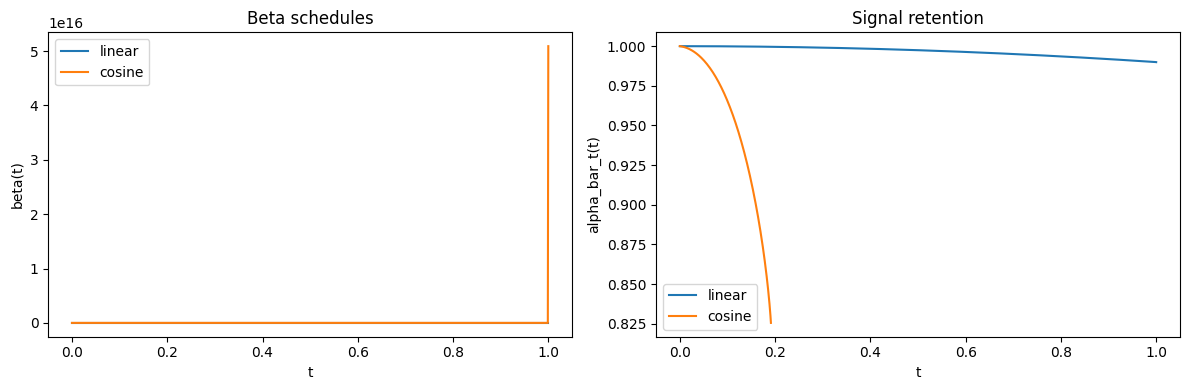

In [65]:
def beta_t_plot(t, config):
    if config.schedule == 'linear':
        return config.beta_min + t * (config.beta_max - config.beta_min)
    elif config.schedule == 'cosine':
        s = 0.008
        angle = (t + s) / (1 + s) * math.pi / 2
        beta = (math.pi / (1 + s)) * math.tan(angle)
        return max(beta, 1e-6)

def plot_schedules():
    ts = np.linspace(0, 1, 1000)

    betas_lin = [beta_t_plot(t, VPConfig(schedule='linear')) for t in ts]
    betas_cos = [beta_t_plot(t, VPConfig(schedule='cosine')) for t in ts]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(ts, betas_lin, label='linear')
    plt.plot(ts, betas_cos, label='cosine')
    plt.xlabel('t')
    plt.ylabel('beta(t)')
    plt.title('Beta schedules')
    plt.legend()

    def alpha_bar_t_plot(t, config):
        dt = 1.0 / config.T
        t_scaled = t * config.T
        indices = int(np.floor(t_scaled))

        log_alpha_bar = 0.0
        for i in range(config.T):
            if indices > i:
                ti = (i + 0.5) / config.T
                log_alpha_bar += np.log(1 - beta_t_plot(ti, config)) * dt

        return np.exp(np.clip(log_alpha_bar, -10, 0))

    alphas_lin = [alpha_bar_t_plot(t, VPConfig(schedule='linear', T=1000)) for t in ts]
    alphas_cos = [alpha_bar_t_plot(t, VPConfig(schedule='cosine', T=1000)) for t in ts]

    plt.subplot(1, 2, 2)
    plt.plot(ts, alphas_lin, label='linear')
    plt.plot(ts, alphas_cos, label='cosine')
    plt.xlabel('t')
    plt.ylabel('alpha_bar_t(t)')
    plt.title('Signal retention')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_schedules()

In [58]:
print("linear + uniform loss")
config_lin_unif = VPConfig(schedule='linear')
trainer_lin_unif = VPTrainer(config_lin_unif, loss_weighting='uniform')
trainer_lin_unif.run()
samples_lin_unif = trainer_lin_unif.sample(1000)

print("linear + SNR weighting")
config_lin_snr = VPConfig(schedule='linear')
trainer_lin_snr = VPTrainer(config_lin_snr, loss_weighting='snr')
trainer_lin_snr.run()
samples_lin_snr = trainer_lin_snr.sample(1000)

print("cosine + uniform loss")
config_cos_unif = VPConfig(schedule='cosine')
trainer_cos_unif = VPTrainer(config_cos_unif, loss_weighting='uniform')
trainer_cos_unif.run()
samples_cos_unif = trainer_cos_unif.sample(1000)

print("linear + SNR weighting")
config_cos_snr = VPConfig(schedule='cosine')
trainer_cos_snr = VPTrainer(config_cos_snr, loss_weighting='snr')
trainer_cos_snr.run()
samples_cos_snr = trainer_cos_snr.sample(1000)

linear + uniform loss
0 0.9923213839530944
200 0.9329841494560241
400 0.8675921738147736
600 0.8270729184150696
800 0.7916991651058197
1000 0.7721623063087464
1200 0.7475626826286316
1400 0.7381273508071899
1600 0.7375245690345764
1800 0.747726708650589
linear + SNR weighting
0 5.020399188995361
200 4.711985301971436
400 4.564519834518433
600 4.0836266040802
800 4.001330137252808
1000 3.860523557662964
1200 3.8003652572631834
1400 3.7107680559158327
1600 3.7782982349395753
1800 3.6300573110580445
cosine + uniform loss
0 0.8998109519481658
200 0.3362088292837143
400 0.3127885669469833
600 0.2945963740348816
800 0.2939335644245148
1000 0.2912827178835869
1200 0.2916890919208527
1400 0.28578086793422697
1600 0.2860457360744476
1800 0.29346037805080416
linear + SNR weighting
0 1.9894495606422424
200 1.269450306892395
400 1.1563108682632446
600 1.1458534896373749
800 1.1110816895961761
1000 1.1149170219898223
1200 1.0442861676216126
1400 1.116759991645813
1600 1.1110828042030334
1800 1.0826

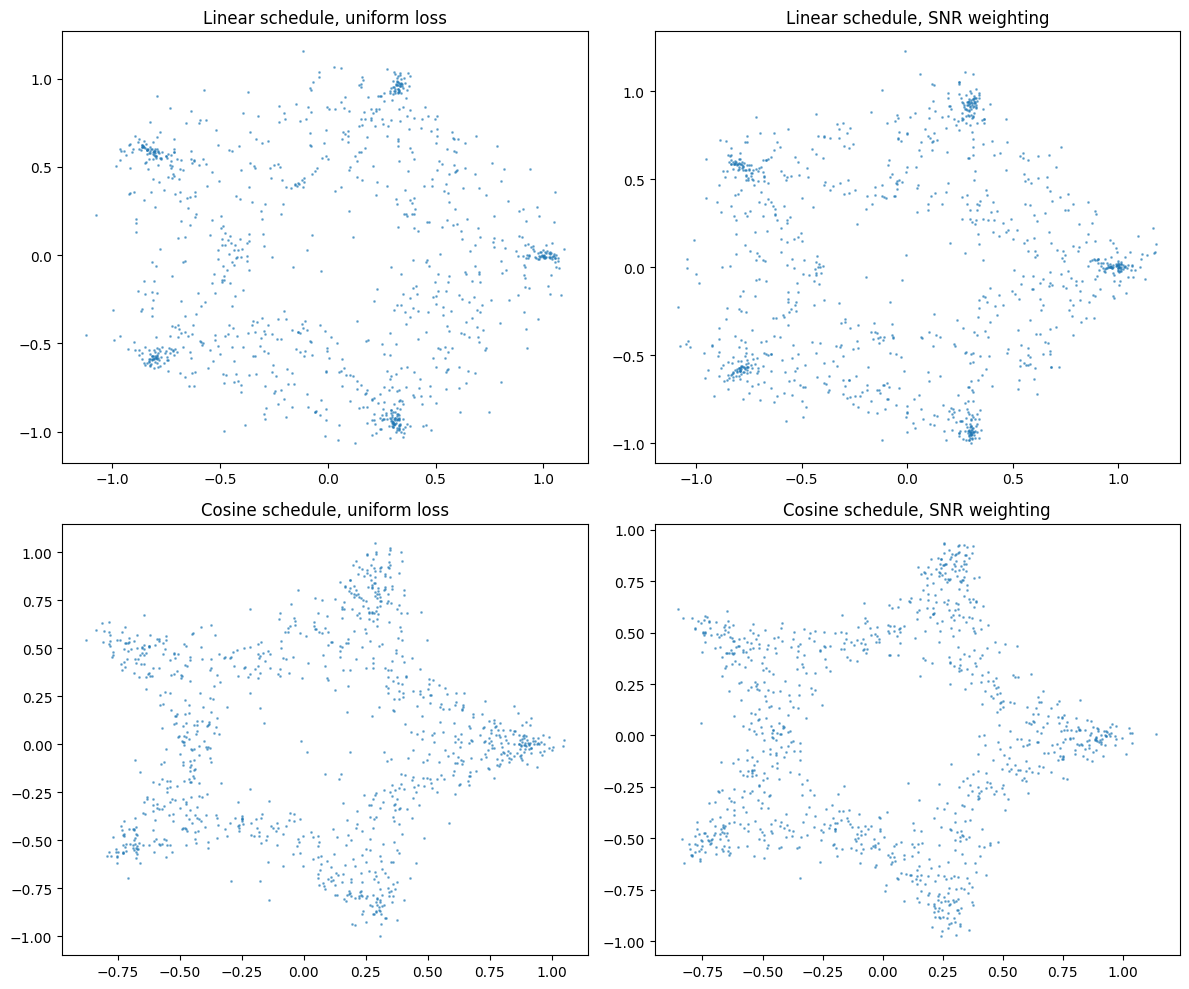

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0,0].scatter(samples_lin_unif[:,0], samples_lin_unif[:,1], s=1, alpha=0.5)
axes[0,0].set_title('Linear schedule, uniform loss')
axes[0,1].scatter(samples_lin_snr[:,0], samples_lin_snr[:,1], s=1, alpha=0.5)
axes[0,1].set_title('Linear schedule, SNR weighting')
axes[1,0].scatter(samples_cos_unif[:,0], samples_cos_unif[:,1], s=1, alpha=0.5)
axes[1,0].set_title('Cosine schedule, uniform loss')
axes[1,1].scatter(samples_cos_snr[:,0], samples_cos_snr[:,1], s=1, alpha=0.5)
axes[1,1].set_title('Cosine schedule, SNR weighting')
plt.tight_layout()
plt.show()

0 41.438622283935544
200 37.51333999633789
400 37.985199737548825
600 37.30322189331055
800 34.160362815856935
1000 36.24263381958008
1200 35.07148456573486
1400 35.09387016296387
1600 33.69457836151123
1800 35.69550132751465


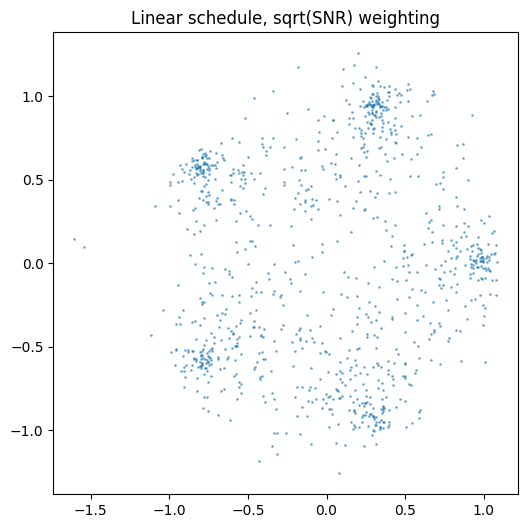

In [60]:
config_lin_sqrt = VPConfig(schedule='linear')
trainer_lin_sqrt = VPTrainer(config_lin_sqrt, loss_weighting='sqrt_snr')
trainer_lin_sqrt.run()
samples_lin_sqrt = trainer_lin_sqrt.sample(1000)

plt.figure(figsize=(6,6))
plt.scatter(samples_lin_sqrt[:,0], samples_lin_sqrt[:,1], s=1, alpha=0.5)
plt.title('Linear schedule, sqrt(SNR) weighting')
plt.show()

In [ ]:
# nvm i just did some BULLSHIIIIIT
# lets do it again

In [61]:
results = {
    ('linear', 'uniform'): {'losses': trainer_lin_unif.run(), 'samples': samples_lin_unif},
    ('linear', 'snr'): {'losses': trainer_lin_snr.run(), 'samples': samples_lin_snr},
    ('cosine', 'uniform'): {'losses': trainer_cos_unif.run(), 'samples': samples_cos_unif},
    ('cosine', 'snr'): {'losses': trainer_cos_snr.run(), 'samples': samples_cos_snr},
}

0 0.7312131941318512
200 0.7150722682476044
400 0.7065036714076995
600 0.6780879855155945
800 0.7025677144527436
1000 0.6946423649787903
1200 0.7018647611141204
1400 0.7182596385478973
1600 0.6892325222492218
1800 0.6800977110862731
0 3.5938069820404053
200 3.5143162965774537
400 3.5461910486221315
600 3.516330027580261
800 3.470763850212097
1000 3.5713469266891478
1200 3.3243364572525023
1400 3.5550069570541383
1600 3.6445695638656614
1800 3.51685791015625
0 0.2754026412963867
200 0.280943238735199
400 0.27697419077157975
600 0.28294957280158994
800 0.27528843879699705
1000 0.2902191042900085
1200 0.2843048065900803
1400 0.2916629403829575
1600 0.27645825147628783
1800 0.28884854912757874
0 1.1072463870048523
200 1.068256640434265
400 1.11048703789711
600 1.075185352563858
800 1.0212988615036012
1000 1.0589713871479034
1200 1.0113370060920714
1400 1.0768729746341705
1600 1.0904634833335876
1800 1.086798405647278


In [62]:
experiments = {
    'linear_uniform': {'losses': results[('linear', 'uniform')]['losses']},
    'linear_snr': {'losses': results[('linear', 'snr')]['losses']},
    'cosine_uniform': {'losses': results[('cosine', 'uniform')]['losses']},
    'cosine_snr': {'losses': results[('cosine', 'snr')]['losses']},
}

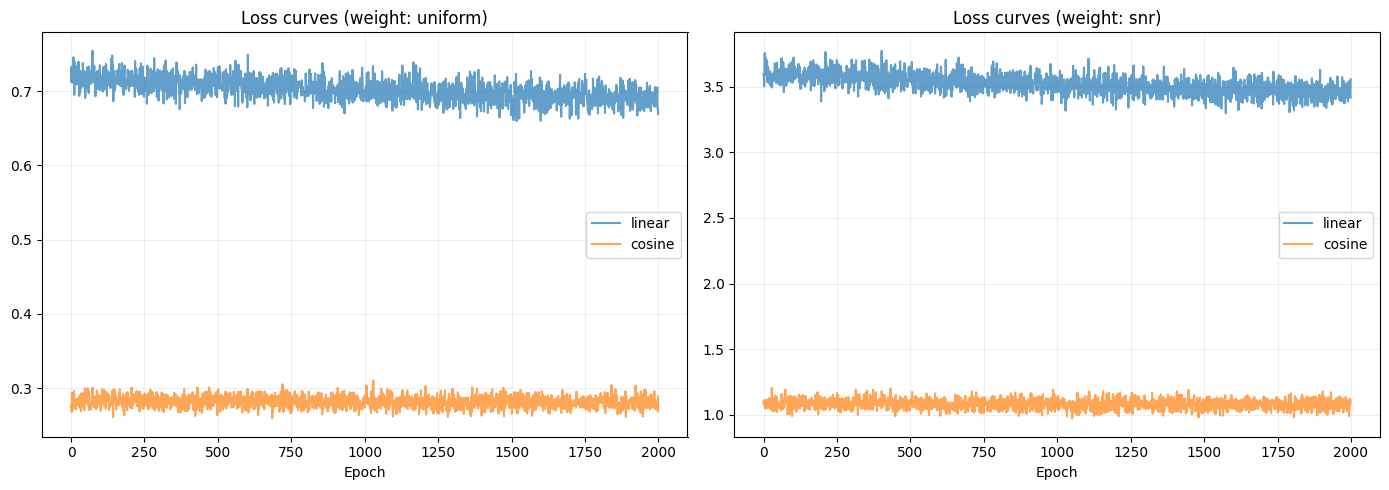

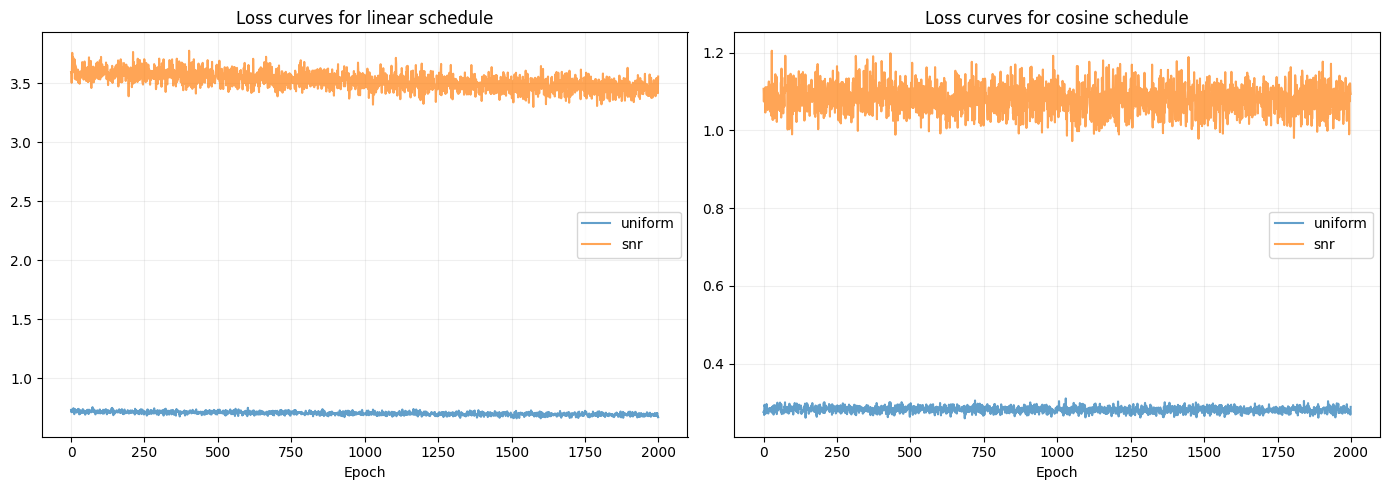

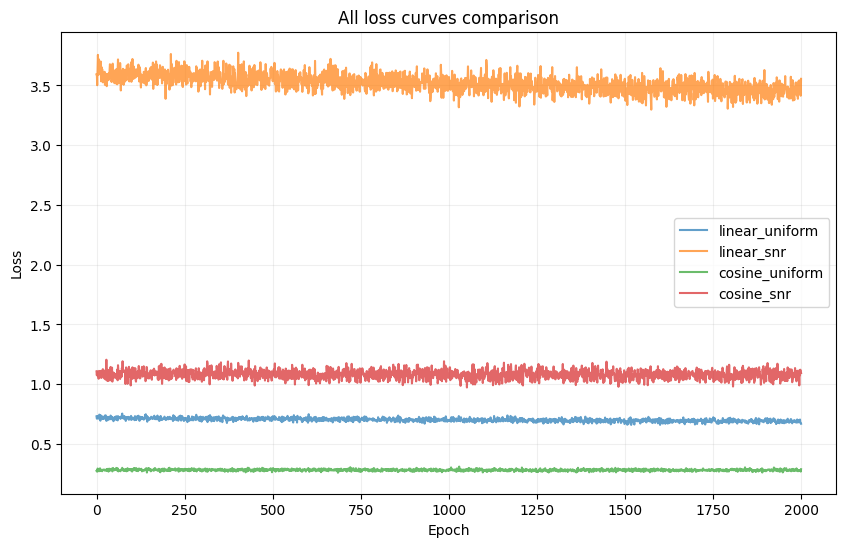

In [63]:
weight_names = ['uniform', 'snr']
sched_names = ['linear', 'cosine']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j, weight in enumerate(weight_names):
    ax = axes[j]
    for sched in sched_names:
        exp = experiments[f'{sched}_{weight}']
        ax.plot(exp['losses'], label=sched, alpha=0.7)
    ax.set_title(f'Loss curves (weight: {weight})')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, sched in enumerate(sched_names):
    ax = axes[i]
    for weight in weight_names:
        exp = experiments[f'{sched}_{weight}']
        ax.plot(exp['losses'], label=weight, alpha=0.7)
    ax.set_title(f'Loss curves for {sched} schedule')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for key in experiments:
    plt.plot(experiments[key]['losses'], label=key, alpha=0.7)
plt.title('All loss curves comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

ВЫВОДЫ:
- VE проще реализовывается и стабильно обучается. дает хороший результат, но VP лучше
- VP дает большую детализацию, но сложнее
- Косинусное расписание дает более плавное убывание alpha_bar_t, сохраняет сигнал на ранних этапах диффузии и уменьшает в конце, так что результат получается более четкий
- линейное расписание дает менее четкие результаты, особенно актуально для лучей
- косинусное расписание сходится быстрее и к более низкому финальному значению потерь
- uniform weighting дает стабильное обучение для обоих расписаний, что гарантирует малое количество шума и хорошую генерацию
- SNR weighting может ускорить обучение, но может приводить к нестабильности
- VP с косинусным расписанием и uniform-взвешиванием дает лучший результат :thumbs-up: